# Stage 1 — Structure & Separation

**Question:** does frozen DINOv2-large feature space actually "know" shrouded vs open rotor?

Thin notebook — it only **imports**, **calls** `src/analysis.py`, and **displays**.
All geometry/statistics live in `src/analysis.py`; labels/Excel in `src/data.py`.

We answer the question four ways that must agree:
1. **Structure report** — per matrix: how many real dimensions, clustering tendency, separation, probe.
2. **Permutation test** — the backbone significance test (is the separation real, or chance?).
3. **Confounds** — is the signal really *design*, or just *who drew the patent* / *when*?
4. **Verdict** — one honest sentence.

Run `10_qc_embeddings.ipynb` first (it produces the embeddings this notebook loads).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / 'config.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config_loader import load_config
from src import data, embeddings, analysis

cfg = load_config()
SEED = cfg['analysis']['seed']

# Reload the per-figure embeddings produced in Stage 0.
result = embeddings.load_embeddings(cfg)
arrays, metadata = result['arrays'], result['metadata']

# Shrouded/open label comes from the FILENAME token (_SHR_ / _OPN_), not the Excel.
yb = analysis.binary_labels(metadata)          # 1 = shrouded, 0 = open
print(f"matrices : {sorted(arrays.keys())}")
print(f"figures  : {len(yb)}  | shrouded={int(yb.sum())}  open={int((1-yb).sum())}")

matrices : [(18, 'cls'), (18, 'mean_patch'), (22, 'cls'), (22, 'mean_patch'), (24, 'cls'), (24, 'mean_patch')]
figures  : 72  | shrouded=32  open=40


## 1 — Structure report (one row per layer × pooling)

For each of the 6 matrices we compute five things:

| column | what it measures | how to read it |
|---|---|---|
| `partic_dim` / `pcs_90` | **intrinsic dimensionality** | of 1024 dims, how many carry real info (≈15–30 here). You can compress this hard. |
| `hopkins` | **clustering tendency** (on PCA-10) | 0.5 = uniform/random, ~1 = clumpy. |
| `sep_ratio` / `p_sep` | **separation** + permutation p | ratio>1 **and** p<0.05 → classes geometrically apart, not by chance. |
| `silhouette` | cleanliness of the 2-class split | ~0 = barely separated, →1 = clean. |
| `probe_auc` / `p_probe` | **linear classifier** (PCA-50, 5-fold CV) | 0.5 = coin-flip, 1.0 = perfect; `p_probe`<0.05 → really decodable. |

In [2]:
report = analysis.structure_report(arrays, yb, n_perm_sep=2000, seed=SEED)

out = Path(cfg['paths']['output_dir']) / 'structure_report.csv'
report.to_csv(out, index=False); print('wrote', out)
report

wrote /mnt/storage_11tb/Drive_files_to_syncronize/4 - Intelligence Models & Post Process Outputs/Preliminary_analysis/outputs/analysis/structure_report.csv


,layer,pooling,partic_dim,pcs_90,hopkins,sep_ratio,p_sep,silhouette,probe_auc,probe_acc,p_probe
0,18,cls,13.2,31,0.64,1.023,0.0790,0.023,0.689,0.695,0.0066
1,18,mean_patch,15.2,35,0.65,1.066,0.0010,0.049,0.708,0.584,0.1495
2,22,cls,21.0,44,0.67,1.087,0.0005,0.069,0.787,0.683,0.0100
3,22,mean_patch,18.5,39,0.59,1.076,0.0005,0.060,0.840,0.779,0.0033
4,24,cls,26.2,48,0.65,1.114,0.0005,0.095,0.836,0.765,0.0033
5,24,mean_patch,18.0,38,0.58,1.122,0.0005,0.097,0.839,0.750,0.0066


**What to take from this table:** find the rows with the highest `probe_auc` /
`sep_ratio` and smallest p-values — those are your best representations (expected:
**layer 22 cls** and **layer 24 mean_patch**). The story should be *consistent but
weak*: significant separation (small `p_sep`), modest probe AUC (~0.7), near-zero
silhouette. That combination = a **real but small** signal, which is exactly what to
expect from *frozen* (un-fine-tuned) features.

## 2 — Confounds: is it *design*, or *drawing style / date*?

The worry: maybe DINOv2 isn't reading the rotor — maybe it recognizes *who drew the
patent* (company drawing conventions) or *when*. We test each confound two ways, and
a confound only biases the result if it is **BOTH**:

- **present** — skewed across the shrouded/open classes, **and**
- **decodable** — readable off the embeddings.

Decodable-but-balanced = a *parallel* signal, not a confound.

In [3]:
# Join the Excel confounds (wired in config.yaml: Assignee, Filing date, ...) and derive axes.
labels = data.load_labels(cfg)
confounds = analysis.derive_confounds(metadata, labels)
confounds.head()

/home/vasco/anaconda3/envs/Finetune/lib/python3.10/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,filing_year,is_bell,assignee_country,publication_country
0,2017,0,CA,CA
1,2018,0,CN,CN
2,2019,0,DE,DE
3,2012,0,DE,EP
4,2019,0,FR,FR


In [4]:
# (a) PRESENT?  is the confound skewed by shrouded/open?  (if 'balanced' -> harmless)
analysis.confound_presence(yb, confounds)

,confound,test,stat_pos,stat_neg,p_value,verdict
0,filing_year,t-test,2017.10,2017.40,0.846,balanced
1,is_bell,chi2,0.42,0.45,1.000,balanced


In [5]:
# (b) DECODABLE?  can the embedding read the confound?  compare to the design probe.
analysis.confound_decodability(arrays, yb, confounds,
                               matrices=[(22, 'cls'), (24, 'mean_patch')], seed=SEED)

,layer,pooling,design_auc,design_p,bell_auc,bell_p,year_r2,year_p
0,22,cls,0.787,0.0100,0.845,0.0033,-0.838,0.1362
1,24,mean_patch,0.839,0.0066,0.729,0.0365,-1.835,0.6512


**How to read these two tables together:**

- If `is_bell` is **balanced** (presence p high) but **decodable** (high `bell_auc`):
  the model *does* encode drawing style, but it runs parallel to design — it does **not**
  explain your shrouded/open result.
- If `filing_year` is **balanced** and its `year_r2` is **negative** (probe worse than
  guessing the mean): no temporal leakage, and DINOv2 carries no usable "filing year"
  information.

That is the ideal outcome: the design signal stands on its own.

## 3 — Deep dive: the permutation separation test (the backbone claim)

`sep_ratio` = (avg distance between a shrouded and an open figure) ÷ (avg distance
between two same-class figures). If labels meant nothing geometrically it would sit at
**1.0**. To see what "nothing" looks like *for these exact points*, we **shuffle the
42/42 labels 10,000 times** and recompute — the blue histogram. Your real value is the
red line; where it falls **is** the p-value.

Watch the two numbers that seem to disagree — **z-score** (how *certain* the effect is
real) vs **effect_size** (how *big* it is). With 84 points → thousands of pairwise
distances, so even a tiny real effect becomes highly significant. **Significance ≠ size.**

layer22_cls: within_shr=0.1239 within_opn=0.1083 between=0.1243 | z=6.8 p=0.0001 effect=0.205
layer24_mean_patch: within_shr=0.1787 within_opn=0.1576 between=0.1860 | z=10.6 p=0.0001 effect=0.342
saved /mnt/storage_11tb/Drive_files_to_syncronize/4 - Intelligence Models & Post Process Outputs/Preliminary_analysis/outputs/analysis/permutation_separation.png


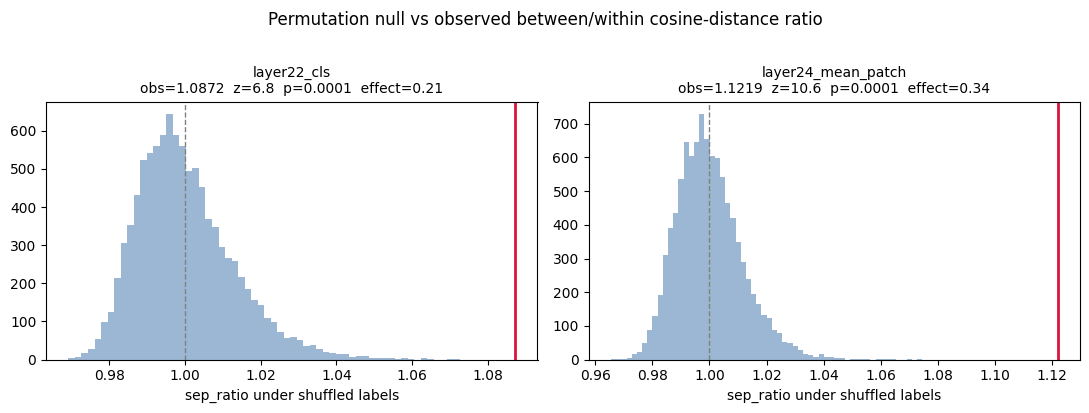

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (L, pool) in zip(axes, [(22, 'cls'), (24, 'mean_patch')]):
    r = analysis.permutation_separation(arrays[(L, pool)], yb, n_perm=10000, seed=SEED)
    ax.hist(r['null'], bins=60, color='#9bb7d4')
    ax.axvline(r['observed'], color='crimson', lw=2)
    ax.axvline(r['null_mean'], color='gray', ls='--', lw=1)
    ax.set_title(f"layer{L}_{pool}\nobs={r['observed']:.4f}  z={r['z_score']:.1f}  "
                 f"p={r['p_value']:.4f}  effect={r['effect_size']:.2f}", fontsize=10)
    ax.set_xlabel('sep_ratio under shuffled labels')
    print(f"layer{L}_{pool}: within_shr={r['within_pos']:.4f} within_opn={r['within_neg']:.4f} "
          f"between={r['between']:.4f} | z={r['z_score']:.1f} p={r['p_value']:.4f} "
          f"effect={r['effect_size']:.3f}")
fig.suptitle('Permutation null vs observed between/within cosine-distance ratio', y=1.02)
fig.tight_layout()
png = Path(cfg['paths']['output_dir']) / 'permutation_separation.png'
fig.savefig(png, dpi=130, bbox_inches='tight'); print('saved', png)
plt.show()

**Reading the plot:** red line = your real separation; blue = what label-shuffling
produces by chance. Red far to the right of the blue mass → real, not chance (tiny p).
But check the x-axis: the observed ratio is only ~1.04–1.06, i.e. between-class distances
are barely ~5% bigger than within-class. **Highly significant, but small.** Report both.

## Verdict

> **Frozen DINOv2-large carries a real, statistically rock-solid, but small
> shrouded-vs-open signal (best at layer 22 cls / layer 24 mean_patch), and that signal
> is genuine — not explained by company drawing-style (balanced across classes) or
> filing year (not even decodable).**

Natural next stage: does **fine-tuning** turn this weak signal into a strong one?